# Activity 3: Train a Small HNN

This notebook shows the complete experiment: synthetic data, network definition, training, evaluation, printed metrics, and plots.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(7)

## Generate and split a toy dataset

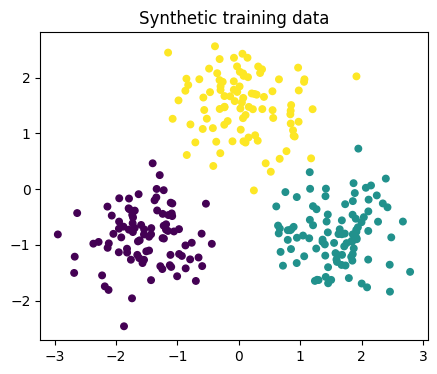

In [2]:
centers = torch.tensor([[-1.5, -0.8], [1.5, -0.8], [0.0, 1.5]])
x = torch.cat([center + 0.55 * torch.randn(120, 2) for center in centers])
y = torch.arange(3).repeat_interleave(120)

permutation = torch.randperm(len(x))
train_ids = permutation[:280]
val_ids = permutation[280:]
x_train, y_train = x[train_ids], y[train_ids]
x_val, y_val = x[val_ids], y[val_ids]

plt.figure(figsize=(5, 4))
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap="viridis", s=22)
plt.title("Synthetic training data")
plt.show()

## Define the geometry

For curvature $K<0$, `expmap0` moves a tangent vector to the Poincaré ball and `logmap0` brings it back.

In [3]:
def expmap0(v, curvature=-1.0):
    sqrt_c = np.sqrt(-curvature)
    norm = v.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    return torch.tanh(sqrt_c * norm) * v / (sqrt_c * norm)


def logmap0(x, curvature=-1.0):
    sqrt_c = np.sqrt(-curvature)
    norm = x.norm(dim=-1, keepdim=True).clamp(1e-8, (1 - 1e-5) / sqrt_c)
    return torch.atanh(sqrt_c * norm) * x / (sqrt_c * norm)

## Define the HNN

**Predict:** Why does the hidden representation need `expmap0` after an ordinary linear transformation?

In [4]:
class HyperbolicLinear(nn.Module):
    def __init__(self, in_features, out_features, curvature=-1.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.curvature = curvature

    def forward(self, x):
        tangent = torch.tanh(self.linear(logmap0(x, self.curvature)))
        return expmap0(tangent, self.curvature)


class HNN(nn.Module):
    def __init__(self, hidden_dim=8, n_classes=3, curvature=-1.0):
        super().__init__()
        self.curvature = curvature
        self.hidden = HyperbolicLinear(2, hidden_dim, curvature)
        self.classifier = nn.Linear(hidden_dim, n_classes)

    def embed(self, x):
        x_hyperbolic = expmap0(0.35 * x, self.curvature)
        return self.hidden(x_hyperbolic)

    def forward(self, x):
        hidden_hyperbolic = self.embed(x)
        hidden_tangent = logmap0(hidden_hyperbolic, self.curvature)
        return self.classifier(hidden_tangent)

## Train

In [5]:
model = HNN(hidden_dim=8, n_classes=3, curvature=-1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
criterion = nn.CrossEntropyLoss()
loss_history = []
val_accuracy_history = []

for epoch in range(151):
    model.train()
    optimizer.zero_grad()
    logits = model(x_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_predictions = model(x_val).argmax(dim=1)
        val_accuracy = (val_predictions == y_val).float().mean().item()

    loss_history.append(loss.item())
    val_accuracy_history.append(val_accuracy)

    if epoch % 30 == 0:
        print(f"Epoch {epoch:3d} | loss {loss.item():.4f} | val accuracy {val_accuracy:.3f}")

Epoch   0 | loss 1.1961 | val accuracy 0.075
Epoch  30 | loss 0.1122 | val accuracy 0.988
Epoch  60 | loss 0.0277 | val accuracy 0.988
Epoch  90 | loss 0.0189 | val accuracy 0.988
Epoch 120 | loss 0.0149 | val accuracy 0.988
Epoch 150 | loss 0.0123 | val accuracy 0.988


## Evaluate and print the result

In [6]:
model.eval()
with torch.no_grad():
    train_accuracy = (model(x_train).argmax(dim=1) == y_train).float().mean().item()
    val_predictions = model(x_val).argmax(dim=1)
    val_accuracy = (val_predictions == y_val).float().mean().item()

print(model)
print(f"Train accuracy: {train_accuracy:.3f}")
print(f"Validation accuracy: {val_accuracy:.3f}")

HNN(
  (hidden): HyperbolicLinear(
    (linear): Linear(in_features=2, out_features=8, bias=True)
  )
  (classifier): Linear(in_features=8, out_features=3, bias=True)
)
Train accuracy: 1.000
Validation accuracy: 0.988


## Plot the decision regions and learning curves

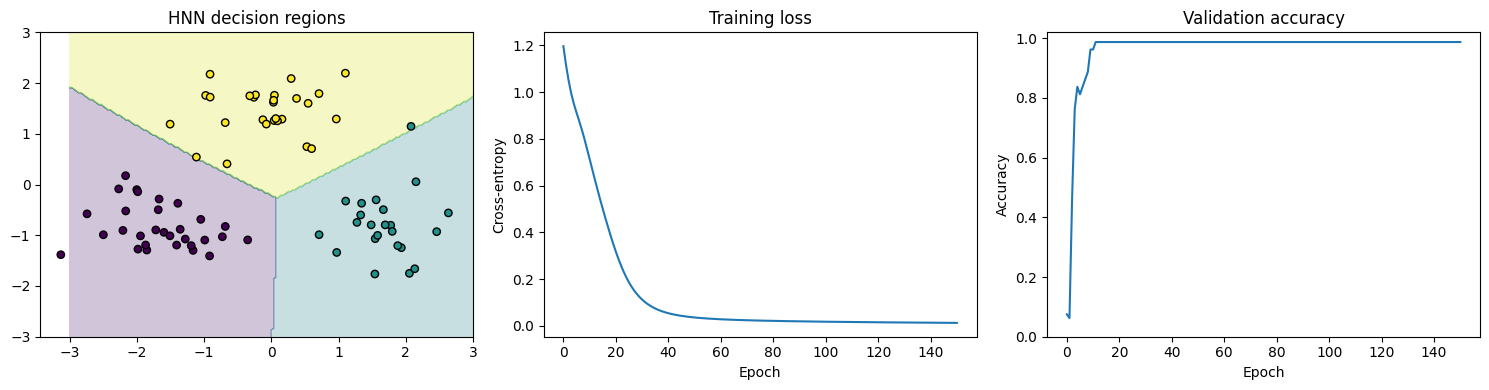

In [7]:
grid_x, grid_y = torch.meshgrid(
    torch.linspace(-3.0, 3.0, 180),
    torch.linspace(-3.0, 3.0, 180),
    indexing="xy",
)
grid = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

with torch.no_grad():
    grid_predictions = model(grid).argmax(dim=1).reshape(grid_x.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].contourf(grid_x, grid_y, grid_predictions, alpha=0.25, cmap="viridis")
axes[0].scatter(x_val[:, 0], x_val[:, 1], c=y_val, cmap="viridis", edgecolor="black", s=28)
axes[0].set_title("HNN decision regions")
axes[1].plot(loss_history)
axes[1].set(xlabel="Epoch", ylabel="Cross-entropy", title="Training loss")
axes[2].plot(val_accuracy_history)
axes[2].set(xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.02), title="Validation accuracy")
plt.tight_layout()
plt.show()

**Modify:** Change `curvature=-1.0` to `curvature=-0.25`, retrain, and compare the boundary and accuracy.